In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")


In [15]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)


In [16]:
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)
titanic.drop("Cabin", axis=1, inplace=True)

titanic["Sex"] = LabelEncoder().fit_transform(titanic["Sex"])
titanic["Embarked"] = LabelEncoder().fit_transform(titanic["Embarked"])

X = titanic.drop(["PassengerId","Name","Ticket","Survived"], axis=1)
y = titanic["Survived"]


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (712, 7)
Test set shape: (179, 7)


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)


lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy*100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"k-NN Classification Accuracy: {knn_accuracy * 100:.2f}%")



k-NN Classification Accuracy: 81.56%


In [21]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})
print("--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))


--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          81.564246


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

titanic_df["Age"].fillna(titanic_df["Age"].median(), inplace=True)
titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0], inplace=True)
titanic_df.drop("Cabin", axis=1, inplace=True)

titanic_df["Sex"] = LabelEncoder().fit_transform(titanic_df["Sex"])
titanic_df["Embarked"] = LabelEncoder().fit_transform(titanic_df["Embarked"])

X_titanic = titanic_df.drop(["PassengerId", "Name", "Ticket", "Survived"], axis=1)
y_titanic = titanic_df["Survived"]

scaler_titanic = StandardScaler()
X_titanic_scaled = scaler_titanic.fit_transform(X_titanic)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_titanic_scaled,
    y_titanic,
    test_size=0.30,
    stratify=y_titanic,
    random_state=42
)

print("Titanic Training Set Shape:", X_train_s.shape)
print("Titanic Test Set Shape:", X_test_s.shape)



Titanic Training Set Shape: (623, 7)
Titanic Test Set Shape: (268, 7)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train)

nb_preds = nb_model.predict(X_test_s)

nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 77.65%


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_train_s = y_train
y_test_s = y_test


svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train_s, y_train_s)


linear_preds = svm_linear.predict(X_test_s)

linear_accuracy = accuracy_score(y_test_s, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 78.21%


In [27]:
sonar_comparison = pd.DataFrame({
    'Classifier': [
        'Gaussian Naïve Bayes (Probabilistic)',
        'Linear Kernel SVM (Maximum-Margin)'
    ],
    'Test Accuracy (%)': [
        nb_accuracy * 100,
        linear_accuracy * 100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")
print(sonar_comparison.to_string(index=False))


--- Performance Comparison on Titanic Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          77.653631
  Linear Kernel SVM (Maximum-Margin)          78.212291


In [28]:
from sklearn.metrics import classification_report

report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived', 'Survived']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.56      0.64      0.60       105
    Survived       0.36      0.28      0.32        74

    accuracy                           0.49       179
   macro avg       0.46      0.46      0.46       179
weighted avg       0.47      0.49      0.48       179



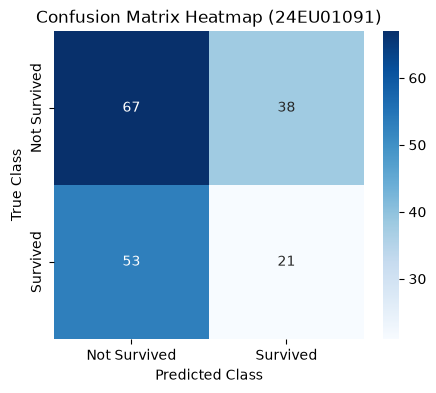

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Confusion Matrix Heatmap (24EU01091)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()


In [30]:
from sklearn.metrics import classification_report

report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived', 'Survived']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.56      0.64      0.60       105
    Survived       0.36      0.28      0.32        74

    accuracy                           0.49       179
   macro avg       0.46      0.46      0.46       179
weighted avg       0.47      0.49      0.48       179



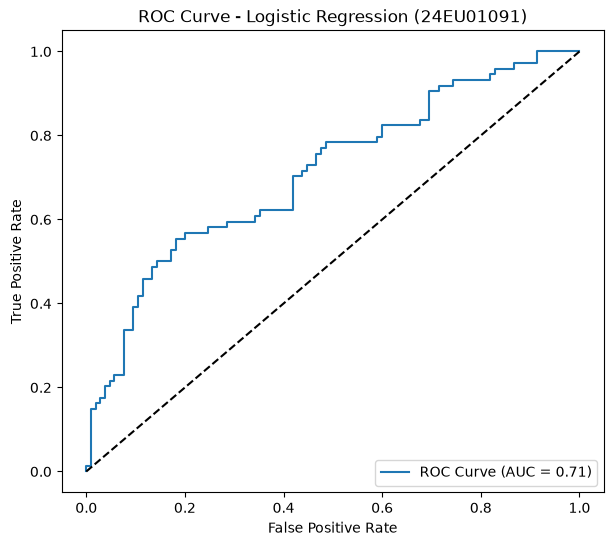

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_score = lr_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (24EU01091)")
plt.legend(loc="lower right")
plt.show()
